In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mc2 = 940
k = 100
hbar_c = 197.3

hbar2_over_2m = (hbar_c**2) / (2 * mc2) 

In [ ]:
def hamiltonian_matrix(delta_r,potential_values):
  potential_values = np.asarray(potential_values,dtype=float)
  if delta_r <=0:
    raise ValueError("detla_r must be greater than 0")
  if potential_values.ndim != 1:
    raise ValueError("potential_values must be a one-dimensional array.")
  if potential_values.size == 0:
    raise ValueError("potential_values cannot be empty.")

  interior_points = len(potential_values)

  main_diag = (2*hbar2_over_2m)/(delta_r**2) + potential_values
  off_diag = np.full(interior_points-1,(-1*hbar2_over_2m)/(delta_r**2))

  hamiltonian = (np.diag(main_diag) + np.diag(off_diag,k=1) + np.diag(off_diag,k=-1))

  return hamiltonian

In [4]:
def effective_potential(r,l,potential):
    potential_values = potential + hbar2_over_2m*(l*(l+1)/(r**2))
    return potential_values

In [9]:
def harmonic_oscillator_potential(interior_grid,k,b):
    return k*(interior_grid**2)/2 + b*(interior_grid**3)/2

In [12]:
def solve_potential(ri,rf,interior_points,l,state_index,k,b):
    delta_r = (rf - ri)/(interior_points + 1)
    interior_grid = (ri + delta_r*np.arange(1,interior_points+1))

    potential = harmonic_oscillator_potential(interior_grid,k,b)
    potential_values = effective_potential(interior_grid,l,potential)

    H = hamiltonian_matrix(delta_r,potential_values)
    eigenvalues,eigenvectors = np.linalg.eigh(H)

    phi_interior   = eigenvectors[:,state_index]
    if phi_interior[np.argmax(np.abs(phi_interior))] < 0:
        phi_interior = -phi_interior
    energy_value   = eigenvalues[state_index]
    phi            = np.concatenate(([0.0],phi_interior,[0.0]))
    normalization  = np.sum(np.abs(phi)**2)*delta_r
    phi_normalized = phi/np.sqrt(normalization)
    full_grid      = np.concatenate(([ri],interior_grid,[rf]))
    
    return full_grid,phi_normalized,energy_value

In [8]:
a = 3
ri = 1e-4 
rf = 20.0  
interior_points = 2000
l = 0
state_index = 0

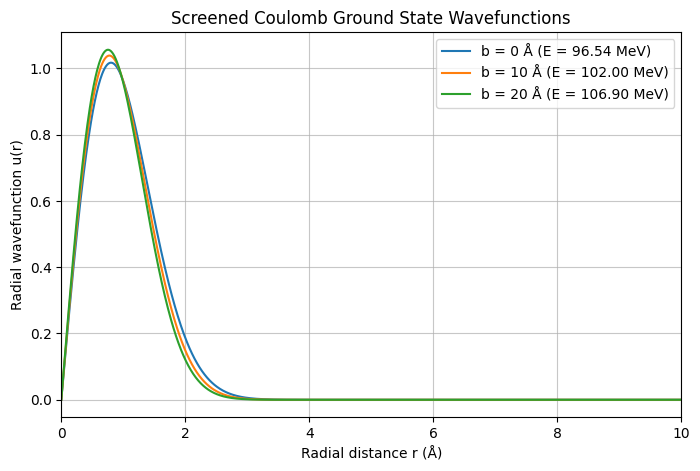

In [14]:
b_list = [0.0,10.0,20.0]

plt.figure(figsize=(8,5))

for b in b_list:
    grid,u_norm,energy = solve_potential(ri,rf,interior_points,l,state_index,k,b)
    plt.plot(grid,u_norm,label=f"b = {b:.0f} Å (E = {energy:.2f} MeV)")

plt.grid(True, alpha=0.7)
plt.xlim(0, 10)
plt.xlabel("Radial distance r (Å)")
plt.ylabel("Radial wavefunction u(r)")
plt.title("Screened Coulomb Ground State Wavefunctions")
plt.legend()
plt.show()